## 1. Importación del dataset Fashion MNIST y librerias 

In [6]:
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from sklearn.metrics import classification_report, confusion_matrix

## 2. Exploracion inical del dataset

**Revisión de dimensiones del dataset**

In [7]:
print("Forma X_train:", X_train.shape)
print("Forma y_train:", y_train.shape)
print("Forma X_test:", X_test.shape)
print("Forma y_test:", y_test.shape)

Forma X_train: (60000, 28, 28)
Forma y_train: (60000,)
Forma X_test: (10000, 28, 28)
Forma y_test: (10000,)


**Definción de los nombres de las clases**

In [8]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
#esto será para mostrar los graficos mas claramente

**Visualización inicial de las imagenes**

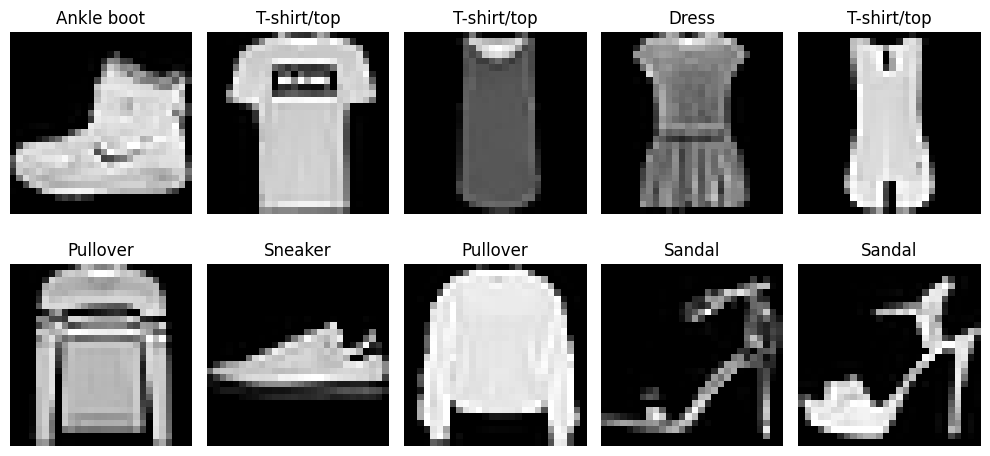

In [11]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

**Verificación de balance de clases**

In [12]:
unique, counts = np.unique(y_train, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"{class_names[cls]}: {count} ejemplos")

T-shirt/top: 6000 ejemplos
Trouser: 6000 ejemplos
Pullover: 6000 ejemplos
Dress: 6000 ejemplos
Coat: 6000 ejemplos
Sandal: 6000 ejemplos
Shirt: 6000 ejemplos
Sneaker: 6000 ejemplos
Bag: 6000 ejemplos
Ankle boot: 6000 ejemplos


## Preprocesamiento

**Normalización de píxeles**

In [ ]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
#Los valores de los píxeles van de 0 a 255. Normalizarlos a un rango 0-1 ayuda a que la red entrene mas rápido y de manera más estable

**Aplanar las imágenes**

In [14]:
X_train = X_train.reshape(-1, 28 * 28)
X_test = X_test.reshape(-1, 28 * 28)

print("Nueva forma X_train:", X_train.shape)  # (60000, 784)
print("Nueva forma X_test:", X_test.shape)    # (10000, 784)

Nueva forma X_train: (60000, 784)
Nueva forma X_test: (10000, 784)


**Separar un set de validación**

In [17]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

print("Train:", X_train.shape, y_train.shape)
print("Validación:", X_val.shape, y_val.shape)
#Se usó stratify=y_train para asegurar que la distribución de clases en el conjunto de validación sea similar a la del conjunto de entrenamiento. Esto es importante para evitar sesgos en la evaluación del modelo.

Train: (48600, 784) (48600,)
Validación: (5400, 784) (5400,)


In [ ]:
print(y_train[:10]) #muestra los primeros 10 valores de y_train 

[4 6 1 7 5 3 4 5 8 0]


**Decisión: etiquetas enteras con `sparse_categorical_crossentropy`**

>Se optó por mantener las etiquetas en formato entero (sin *one-hot encoding*), utilizando la función de pérdida `sparse_categorical_crossentropy`. Esta alternativa es matemáticamente equivalente a `categorical_crossentropy` con etiquetas *one-hot*, pero resulta más eficiente en memoria y reduce el riesgo de errores de codificación, siendo el enfoque recomendado por la documentación oficial de Keras para problemas de clasificación multiclase con etiquetas enteras.

## 4. Definición del Modelo: Arquitectura MLP

**Arquitectura base**

In [23]:
model = Sequential([
    Input(shape=(784,)),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

**Compilar el modelo**

In [24]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

**Entrenamiento**

In [25]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7836 - loss: 0.6045 - val_accuracy: 0.8437 - val_loss: 0.4337
Epoch 2/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8376 - loss: 0.4476 - val_accuracy: 0.8570 - val_loss: 0.3956
Epoch 3/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8501 - loss: 0.4102 - val_accuracy: 0.8617 - val_loss: 0.3739
Epoch 4/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8584 - loss: 0.3906 - val_accuracy: 0.8659 - val_loss: 0.3667
Epoch 5/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8614 - loss: 0.3735 - val_accuracy: 0.8719 - val_loss: 0.3555
Epoch 6/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8691 - loss: 0.3572 - val_accuracy: 0.8737 - val_loss: 0.3391
Epoch 7/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8710 - loss: 0.3503 - val_accuracy: 0.8756 - val_loss: 0.3259
Epoch 8/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8733 - loss: 0.3401 - 

**Graficos de las curvas de entrenamiento**

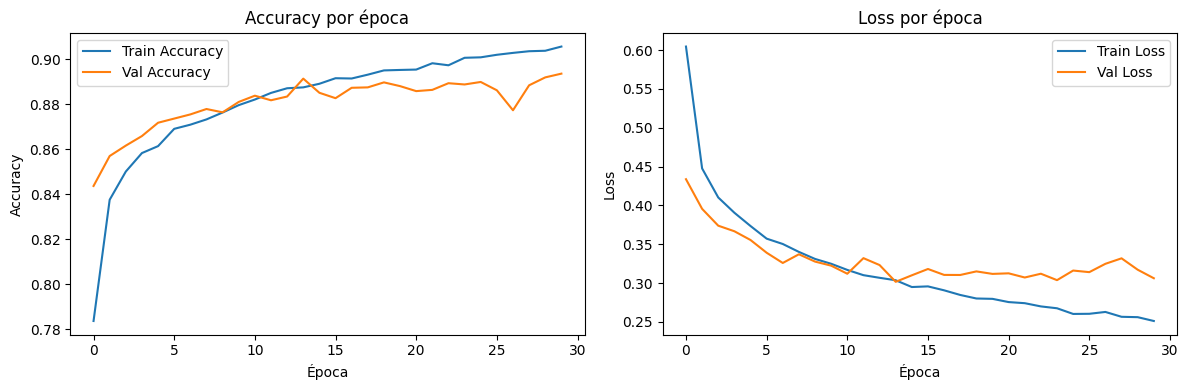

In [26]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.title('Accuracy por época')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Loss por época')
plt.legend()

plt.tight_layout()
plt.show()

**Evaluación en el set de test**

In [27]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 0.8828
Test Loss: 0.3422


**Métricas del modelo y matriz de confusión**

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 696us/step
              precision    recall  f1-score   support

 T-shirt/top       0.88      0.79      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.81      0.76      0.79      1000
       Dress       0.86      0.92      0.89      1000
        Coat       0.78      0.82      0.80      1000
      Sandal       0.99      0.94      0.97      1000
       Shirt       0.69      0.72      0.70      1000
     Sneaker       0.91      0.98      0.95      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.96      0.94      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



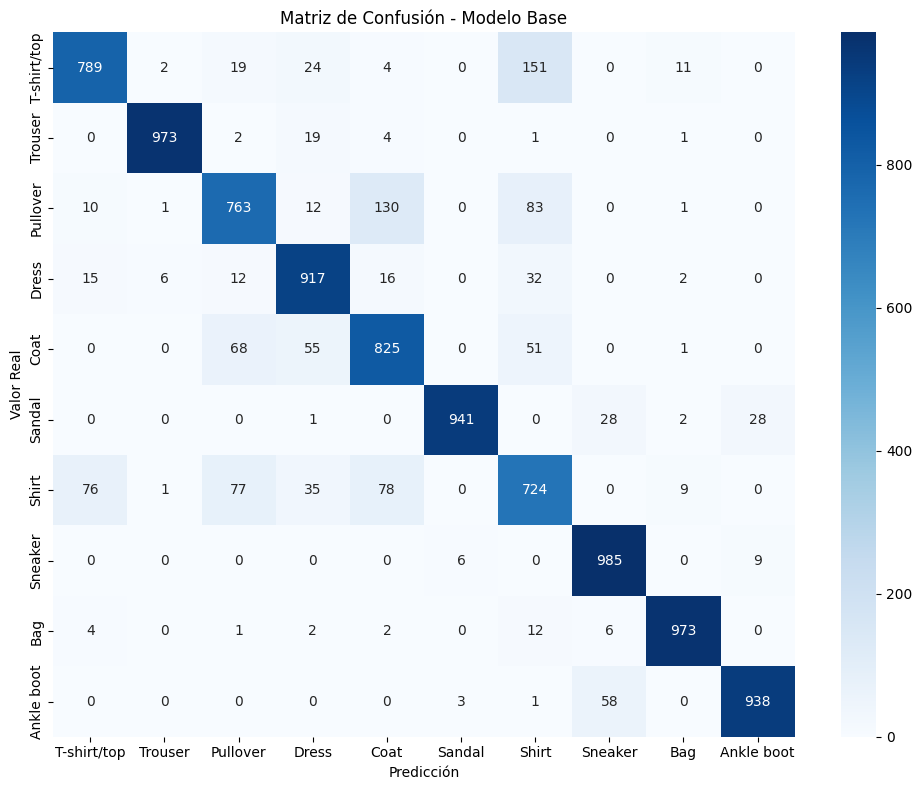

In [29]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión - Modelo Base')
plt.tight_layout()
plt.show()

## Interpretación de Resultados — Modelo Base

### Métricas generales

El modelo base (MLP con arquitectura 256-128-10, dropout 0.3, 30 épocas, batch size 32) 
alcanzó un **accuracy de test de 88.28%**, con un F1-score promedio (macro) de 0.88.

### Análisis por clase

El desempeño no es uniforme entre las 10 clases. Se observan dos grupos claramente diferenciados:

**Clases con excelente desempeño (F1 > 0.94):**
- Trouser (0.98), Sandal (0.97), Bag (0.97), Sneaker (0.95), Ankle boot (0.95)

Estas categorías tienen formas muy distintivas y fácilmente separables del resto 
(ej. un pantalón no se parece a un zapato), lo que explica su alto rendimiento.

**Clases con desempeño más débil (F1 < 0.83):**
- Shirt (0.70), Pullover (0.79), Coat (0.80), T-shirt/top (0.83)

### Análisis de la matriz de confusión

La matriz de confusión confirma un patrón claro de error concentrado entre prendas 
de "torso superior":

- **Shirt** es la clase más problemática: de 1000 ejemplos reales, solo 724 se 
  clasificaron correctamente. Los errores se distribuyen principalmente hacia:
  - T-shirt/top (76 casos)
  - Pullover (77 casos)
  - Coat (78 casos)
- **T-shirt/top** se confunde 151 veces con Shirt — la confusión es bidireccional.
- **Pullover** se confunde 130 veces con Coat.

En contraste, clases como Trouser, Sandal, Sneaker y Bag presentan muy pocos errores 
y, cuando los hay, tienden a distribuirse entre categorías igualmente distantes 
(ej. Sandal ↔ Sneaker ↔ Ankle boot, todas calzado).

### Interpretación

El patrón de errores es consistente con una limitación estructural del MLP: al aplanar 
cada imagen 28x28 en un vector de 784 valores, **se pierde toda la información espacial** 
(relación entre píxeles vecinos). Prendas como Shirt, Pullover, Coat y T-shirt/top 
comparten una silueta rectangular muy similar, diferenciándose principalmente por 
detalles finos (cuello, mangas, textura, largo) que dependen de relaciones espaciales 
locales entre píxeles — información que el MLP no puede aprovechar de la misma forma 
que lo haría una arquitectura convolucional (CNN).
